Устанавливаем и импортируеи необходимые библиотеки, а также фиксируеи начальные значения всех генераторов случайных чисел для гарантии воспроизводимости результатов модели.

In [1]:
# Устанавливаем необходимые библиотеки
!pip install numpy matplotlib tensorflow pandas scikit-learn --quiet

import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf

# Фиксация генераторов случайных чисел для воспроизводимости результатов
SEED = 0
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

 Импортируем необходимые библиотеки для построения LSTM-модели (Sequential, Input, LSTM, Dense), масштабирования данных (MinMaxScaler) и визуализации результатов (matplotlib, seaborn), а также настраиваем стиль и размер графиков.

In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

Загружаем данные из файла в таблицу Pandas, выводим первые строки для ознакомления со структурой и подсчитываем количество пропущенных значений (NaN) в каждом столбце.

In [3]:
# Загружаем датасет
df_dirty = pd.read_csv("MSFT_corrupted.csv")

print("Первые строки датасета:")
display(df_dirty.head())

print("\nПроверка пропусков (NaN):")
print(df_dirty.isna().sum())

Первые строки датасета:


,date,open,high,low,close,volume,Name
0,2015-11-18,53.00,53.98,52.9799,53.85,29710030,MSFT
1,2015-11-19,53.99,54.66,53.7810,53.94,28149228,MSFT
2,2015-11-20,54.25,54.30,53.2650,54.19,37147608,MSFT
3,2015-11-23,54.25,54.46,53.7500,54.19,28235918,MSFT
4,2015-11-24,53.92,54.44,53.5800,54.25,24600043,MSFT



Проверка пропусков (NaN):
date      0
open      5
high      5
low       5
close     5
volume    0
Name      0
dtype: int64


Создаем копию датафрейма, преобразуем столбец с датами в формат datetime и восстанавливаем пропущенные значения в числовых колонках, используя линейную интерполяцию и метод обратного заполнения (bfill) для начальных пропусков.

In [4]:
# Очистка данных: интерполяция пропусков линейным методом (заполнение между известными точками)
df = df_dirty.copy()
df['date'] = pd.to_datetime(df['date'])

# Интерполируем только числовые столбцы
num_cols = ['open', 'high', 'low', 'close', 'volume']
df[num_cols] = df[num_cols].interpolate(method='linear').bfill() # bfill для первых NaN

print(f"Датасет очищен. Осталось строк: {len(df)}")

Датасет очищен. Осталось строк: 559


Визуализируем динамику цены закрытия акций MSFT на графике и создаём новый датафрейм train_df, содержащий только целевой столбец 'close' для дальнейшего обучения модели.

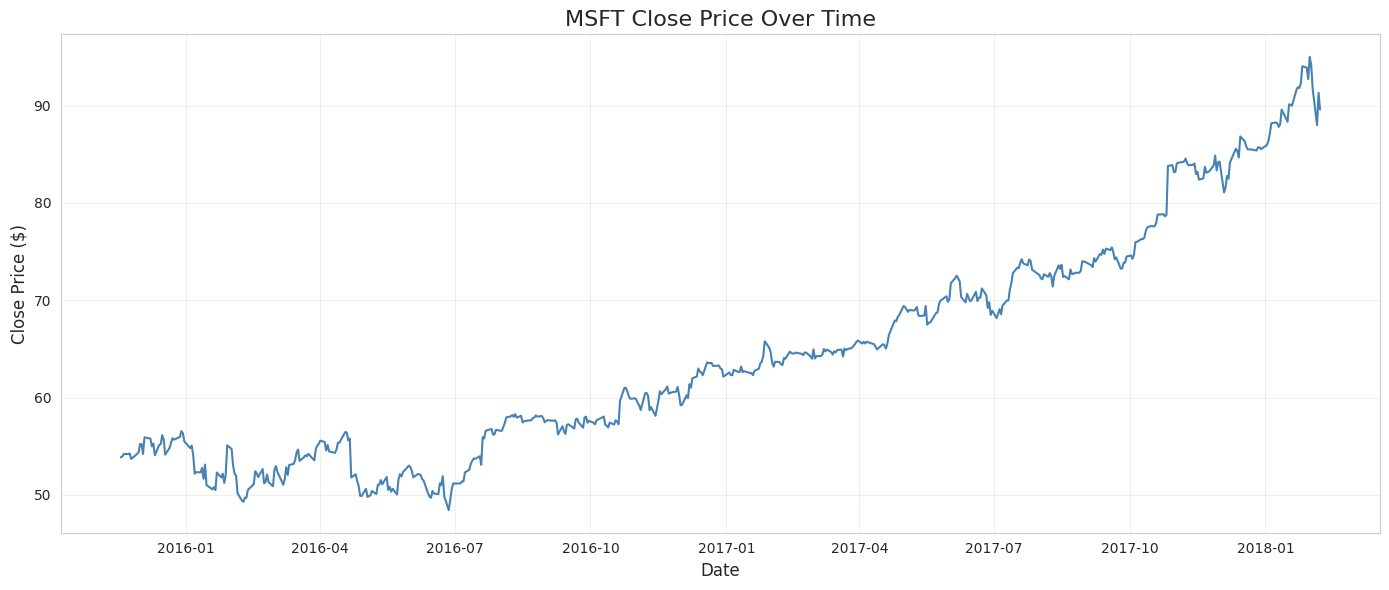

Форма данных для обучения: (559, 1)


In [5]:
# Строим график цены закрытия
plt.plot(df['date'], df['close'], color='steelblue', linewidth=1.5)
plt.title('MSFT Close Price Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Close Price ($)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Оставляем только целевой столбец для модели
train_df = df[['close']].copy()
print(f"Форма данных для обучения: {train_df.shape}")

Задаем гиперпараметры эксперимента (количество эпох, длину последовательности, коэффициент разбиения) и вычисляем размеры тренировочной (95%) и тестовой (5%) выборок.

In [6]:
# Константы эксперимента
EPOCHS = 10
DAYS = 10
SPLIT_VALUE = 0.95

# Индекс разбиения
training_data_len = int(len(train_df) * SPLIT_VALUE)
print(f"Длина тренировочной выборки: {training_data_len}")
print(f"Длина тестовой выборки: {len(train_df) - training_data_len}")

Длина тренировочной выборки: 531
Длина тестовой выборки: 28


Масштабируем цены в диапазон [0, 1], формируем из них скользящие последовательности для признаков и целевых значений, преобразуем входные данные в трёхмерный формат, требуемый для LSTM-сети, и выводим итоговые размеры массивов.

In [7]:
# Масштабирование данных в диапазон [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(train_df.values)

# Создаем X_train и y_train
train_data = scaled_data[:training_data_len, :]
x_train, y_train = [], []

for i in range(DAYS, len(train_data)):
    x_train.append(train_data[i-DAYS:i, 0])
    y_train.append(train_data[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

print(f"x_train shape: {x_train.shape} | y_train shape: {y_train.shape}")

x_train shape: (521, 10, 1) | y_train shape: (521,)


Эта ячейка создаёт, компилирует и обучает рекуррентную нейронную сеть из двух слоёв LSTM и двух полносвязных слоёв для предсказания цены акций на подготовленных данных.

In [8]:
model = Sequential()
model.add(Input(shape=(DAYS, 1)))
model.add(LSTM(50, return_sequences=True))  # Первый LSTM слой
model.add(LSTM(50, return_sequences=False)) # Второй LSTM слой
model.add(Dense(25, activation='relu'))     # Скрытый Dense слой
model.add(Dense(1))                         # Выходной слой (1 нейрон -> цена)

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

# Обучение модели
history = model.fit(x_train, y_train, batch_size=1, epochs=EPOCHS, verbose=1)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.0036
Epoch 2/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0015
Epoch 3/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0013
Epoch 4/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0012
Epoch 5/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0011
Epoch 6/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 9.8028e-04
Epoch 7/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 8.6064e-04
Epoch 8/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 7.3461e-04
Epoch 9/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 6.2991e-04
Epoch 10/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 5.8821e-04


Формируем тестовую выборку, получаем предсказания обученной LSTM-модели и визуализируем их сравнение с реальными ценами акций на тестовом периоде.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step


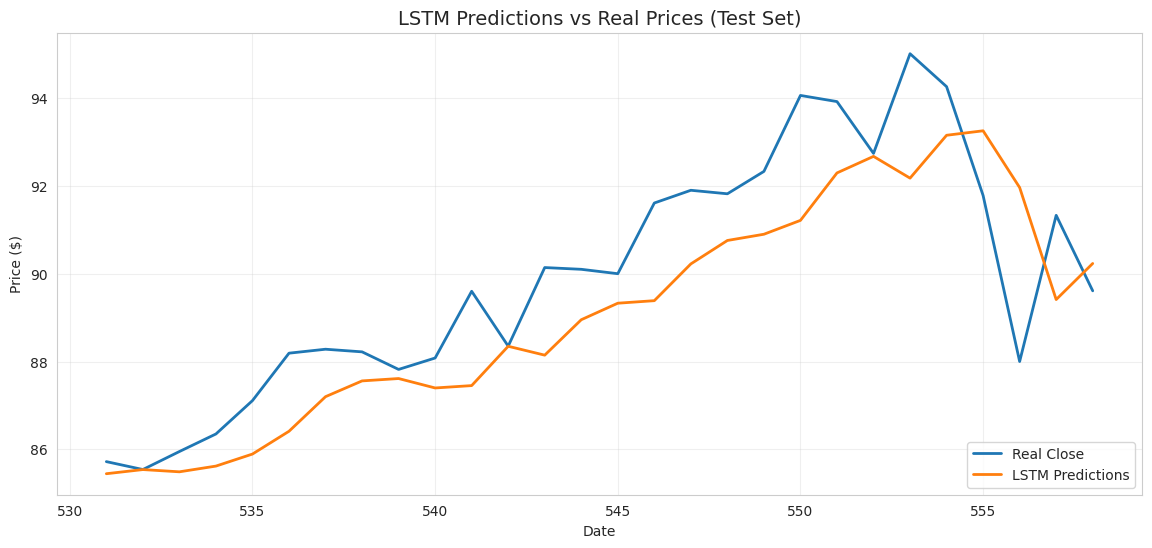

In [9]:
# Формируем тестовые данные
test_data = scaled_data[training_data_len - DAYS:, :]
x_test, y_test = [], []
for i in range(DAYS, len(test_data)):
    x_test.append(test_data[i-DAYS:i, 0])
    y_test.append(test_data[i, 0])
x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

# Предсказания модели
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

# Подготовка DataFrame для графика
valid = train_df[training_data_len:].copy()
valid['close'] = valid['close'].values
valid['predictions'] = predictions

plt.plot(valid[['close', 'predictions']], linewidth=2)
plt.legend(['Real Close', 'LSTM Predictions'], loc='lower right')
plt.title('LSTM Predictions vs Real Prices (Test Set)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.grid(True, alpha=0.3)
plt.show()

Реализуем простую step-1 модель, проверяем совпадение размеров предсказаний и визуализируем сравнение её работы с LSTM-моделью на тестовых данных.

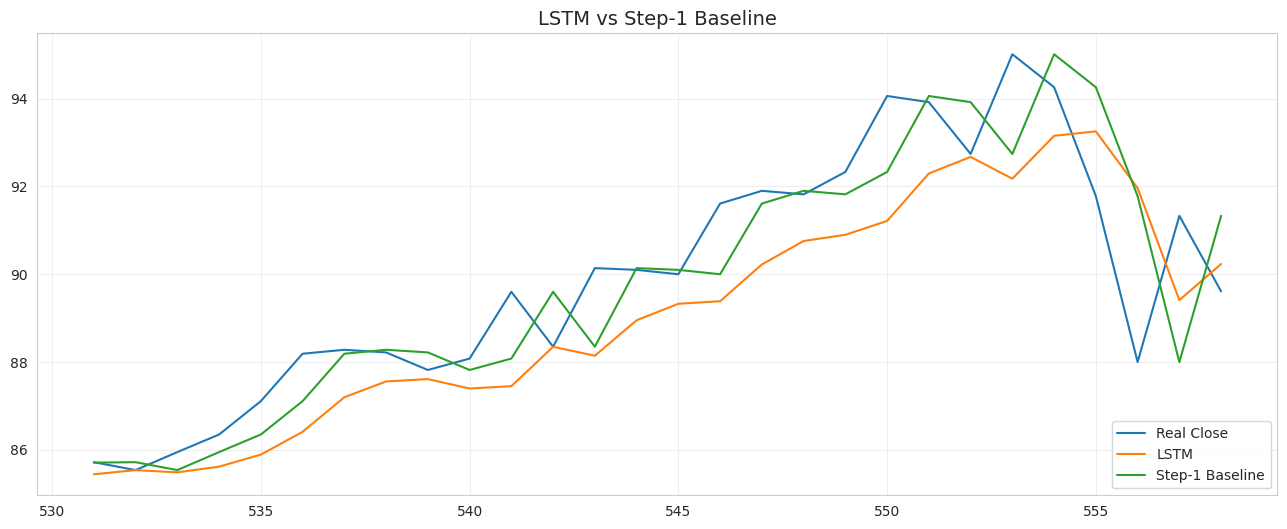

In [11]:
# Длина массива предсказаний модели
N = len(predictions)

# Берём реальные значения, начиная с последнего дня обучения + все тестовые дни
# Нам нужно N+1 значение, чтобы сформировать N предсказаний со сдвигом
real_values = train_df['close'].values[training_data_len - 1 : training_data_len - 1 + N + 1]

# Step-1 модель: предсказание для дня i = значение дня i-1
predictions_step = real_values[:-1].reshape(-1, 1)  # Берём первые N значений

# Проверяем, что длины совпали
assert predictions.shape == predictions_step.shape, f"Размеры не совпадают: predictions {predictions.shape} vs step {predictions_step.shape}"

# Добавляем в DataFrame и строим график
valid['predictions_step'] = predictions_step
plt.figure(figsize=(16, 6))
plt.plot(valid[['close', 'predictions', 'predictions_step']], linewidth=1.5)
plt.legend(['Real Close', 'LSTM', 'Step-1 Baseline'], loc='lower right')
plt.title('LSTM vs Step-1 Baseline', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

Далее выполняем независимое прогнозирование, при котором модель предсказывает будущие значения, последовательно используя свои собственные предсказания в качестве входных данных вместо реальных, и визуализирует результат.

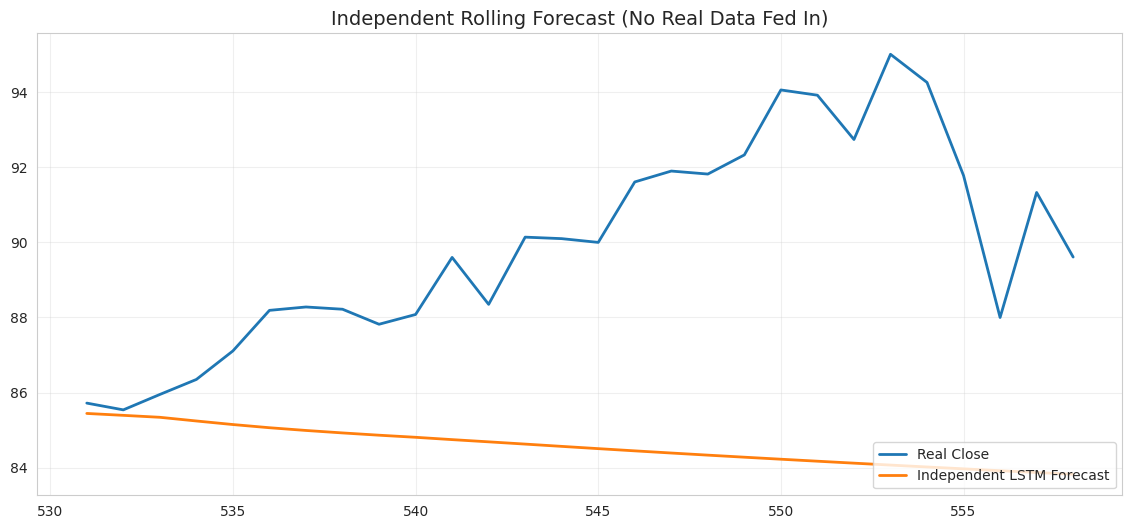

In [12]:
# Предсказание только на основе начальных данных, без подмешивания реальных значений
x_test_independent = scaled_data[training_data_len - DAYS:training_data_len, 0].reshape(1, DAYS, 1)
indep_preds = []

for i in range(len(valid)):
    # Предсказываем следующее значение
    pred = model.predict(x_test_independent, verbose=0)[0, 0]
    indep_preds.append(pred)

    # Обновляем окно: удаляем самый старый, добавляем предсказанный
    seq = x_test_independent.reshape(-1)
    seq = np.append(seq[1:], pred)
    x_test_independent = seq.reshape(1, DAYS, 1)

indep_preds = scaler.inverse_transform(np.array(indep_preds).reshape(-1, 1))
valid['predictions_indep'] = indep_preds

plt.plot(valid[['close', 'predictions_indep']], linewidth=2)
plt.legend(['Real Close', 'Independent LSTM Forecast'], loc='lower right')
plt.title('Independent Rolling Forecast (No Real Data Fed In)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

Вычисляем и добавляем три признака скользящего среднего (за 7, 14 и 28 дней), очищаем датафрейм от строк с пропущенными значениями и выводим его новую длину.

In [16]:
# 1. Создаем признаки Moving Average
ma_df = train_df.copy()
ma_df['ma7']  = ma_df['close'].rolling(window=7).mean()
ma_df['ma14'] = ma_df['close'].rolling(window=14).mean()
ma_df['ma28'] = ma_df['close'].rolling(window=28).mean()
# Удаляем строки с NaN (первые 28 строк будут пустыми)
ma_df = ma_df.dropna().reset_index(drop=True)
print(f"Длина датасета после MA-признаков: {len(ma_df)}")

Длина датасета после MA-признаков: 532


Затем разделяем данные на входные признаки и целевую переменную, после чего независимо масштабируем их в диапазон от 0 до 1.

In [17]:
# 2. Разделяем признаки (X) и цель (y)
features = ma_df[['ma7', 'ma14', 'ma28']].values
target   = ma_df[['close']].values

# Масштабируем отдельно
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

X_scaled = scaler_X.fit_transform(features)
y_scaled = scaler_y.fit_transform(target)


Эта ячейка разделяет подготовленные данные на обучающую и тестовую выборки и преобразует их в последовательности скользящих окон, необходимые для обучения и тестирования LSTM-модели.

In [18]:
# 3. Разбиваем на train/test
training_len_ma = int(len(ma_df) * SPLIT_VALUE)
train_X_raw = X_scaled[:training_len_ma]
train_y_raw = y_scaled[:training_len_ma]
test_X_raw  = X_scaled[training_len_ma - DAYS:]
test_y_raw  = y_scaled[training_len_ma - DAYS:]

def make_sequences(X, y, days):
    X_seq, y_seq = [], []
    for i in range(days, len(X)):
        X_seq.append(X[i-days:i, :])
        y_seq.append(y[i, 0])
    return np.array(X_seq), np.array(y_seq)

x_train_ma, y_train_ma = make_sequences(train_X_raw, train_y_raw, DAYS)
x_test_ma,  y_test_ma  = make_sequences(test_X_raw,  test_y_raw,  DAYS)

Создаем, компилируем и обучаем новую LSTM-модель, использующую три признака скользящего среднего в качестве входных данных для предсказания цены на тренировочной выборке.

In [19]:
# 4. Новая модель LSTM на MA-признаках
model_ma = Sequential()
model_ma.add(Input(shape=(DAYS, 3))) # 3 признака: ma7, ma14, ma28
model_ma.add(LSTM(50, return_sequences=False))
model_ma.add(Dense(1))

model_ma.compile(optimizer='adam', loss='mean_squared_error')
history_ma = model_ma.fit(x_train_ma, y_train_ma, batch_size=1, epochs=EPOCHS, verbose=0)

Далее преобразуем предсказания модели и реальные значения из нормализованного диапазона [0, 1] обратно в исходный масштаб цен акций для корректного сравнения и визуализации результатов.

In [20]:
# 5. Предсказания и обратное преобразование
pred_ma_scaled = model_ma.predict(x_test_ma)
pred_ma = scaler_y.inverse_transform(pred_ma_scaled)
y_test_ma_real = scaler_y.inverse_transform(y_test_ma.reshape(-1, 1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


Реализуем step-1 базлайн для MA-датасета, создавая предсказания путём сдвига реальных значений на один день вперёд

In [22]:
# 6. Step-1 базлайн для MA-датасета

real_close_ma = valid_ma['close'].values
last_train_value = ma_df.iloc[training_len_ma - 1]['close']
pred_step_ma = np.concatenate([[last_train_value], real_close_ma[:-1]])
pred_step_ma = pred_step_ma.reshape(-1, 1)


В конце визуализируем и сравниваем предсказания MA-LSTM модели и базовой модели Step-1 с реальными значениями цены акций на тестовом периоде.

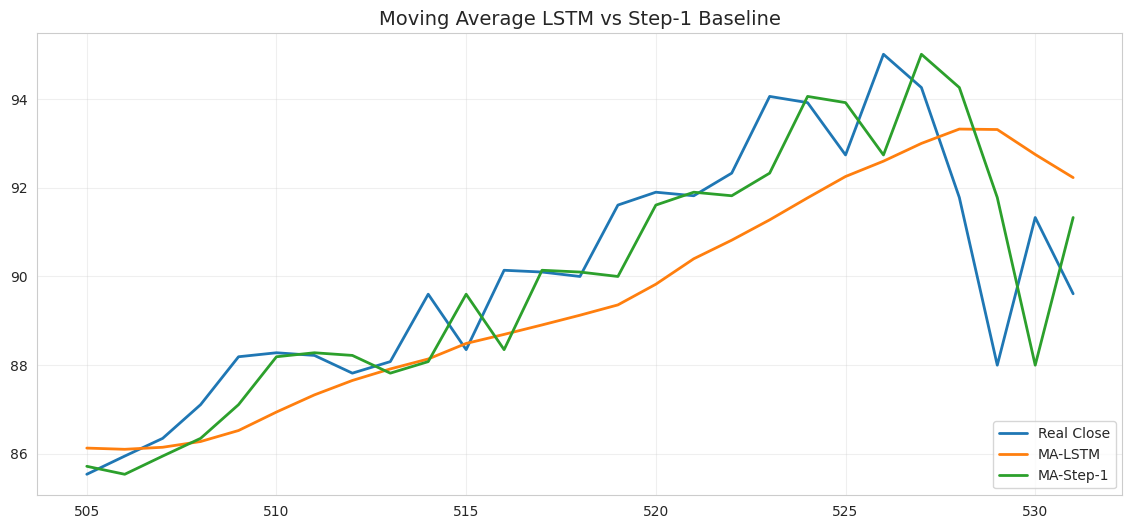

In [24]:
# 7. График сравнения
valid_ma['predictions_ma'] = pred_ma
valid_ma['predictions_step_ma'] = pred_step_ma

plt.plot(valid_ma[['close', 'predictions_ma', 'predictions_step_ma']], linewidth=2)
plt.legend(['Real Close', 'MA-LSTM', 'MA-Step-1'], loc='lower right')
plt.title('Moving Average LSTM vs Step-1 Baseline', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

Модель на Moving Average сглаживает шум и лучше улавливает общий тренд, но отстаёт от резких изменений цены, так как опирается на усреднённые исторические данные.